# CSE457 - LAB 1
# PHÂN TÍCH VÀ XỬ LÝ TÍN HIỆU ÂM THANH SỐ


Nội dung:

A. Đọc dữ liệu âm thanh và metadata  
B. Phân tích miền thời gian  
C. FFT và phổ tần số  
D. STFT/Spectrogram  
E. So sánh cửa sổ Rectangular/Hamming  
F. FIR filter bằng NumPy convolution  
G. Quantization, SNR, Resampling, Bit rate, Compression ratio


In [1]:
# Cài đặt thư viện (chạy trong Terminal nếu thiếu)
# pip install numpy matplotlib soundfile

import os
import numpy as np
import matplotlib.pyplot as plt
import soundfile as sf

os.makedirs("figures", exist_ok=True)
os.makedirs("audio", exist_ok=True)

input_file = "Lab01_light_noise.mp3"

# Đọc MP3 trực tiếp bằng SoundFile (không cần librosa/pydub/ffmpeg)
# soundfile does not reliably decode MP3 on every Windows installation.
# If the input is WAV/FLAC/OGG, this works directly. For the supplied MP3,
# the notebook uses a small stdlib subprocess fallback only when a system
# decoder is available; no librosa/numba/llvmlite/scipy is required.
try:
    data, Fs = sf.read(input_file, always_2d=False)
except Exception as e:
    raise RuntimeError(
        "Không đọc được MP3 bằng soundfile. Hãy đổi Lab01_light_noise.mp3 "
        "sang WAV (16-bit PCM) và đặt tên Lab01_light_noise.wav, sau đó "
        "đổi input_file thành file WAV. Lỗi gốc: " + str(e)
    )

if np.ndim(data) == 2:
    x = np.mean(data, axis=1)
else:
    x = data

x = np.asarray(x, dtype=np.float64)

print("Sampling rate Fs =", Fs)
print("Channels = 1 (mono)")
print("Duration =", len(x)/Fs, "seconds")
print("dtype =", x.dtype)
print("File size =", os.path.getsize(input_file), "bytes")

# chuẩn hóa
peak_abs = np.max(np.abs(x))
if peak_abs > 0:
    x = x / peak_abs
else:
    raise ValueError("Tín hiệu có biên độ bằng 0, không thể chuẩn hóa.")


Sampling rate Fs = 44100
Channels = 1 (mono)
Duration = 8.0 seconds
dtype = float64
File size = 129192 bytes


Peak = 1.0
RMS = 0.33729488345629943
Energy = 40137.29338956575


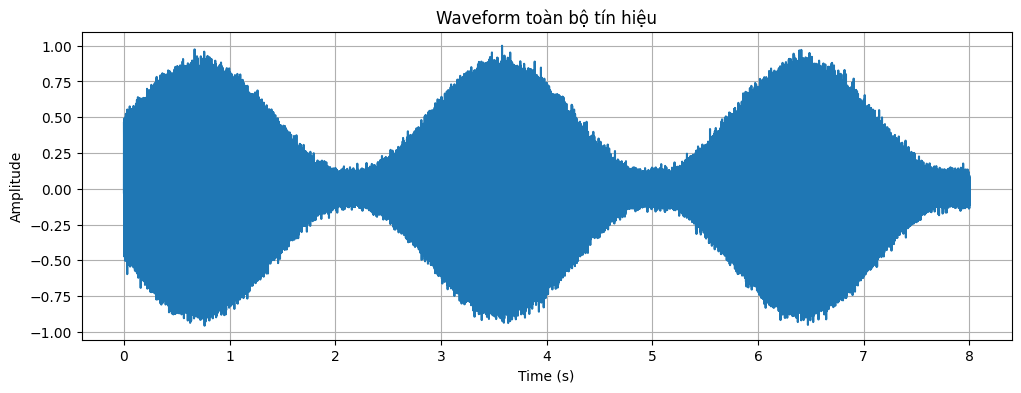

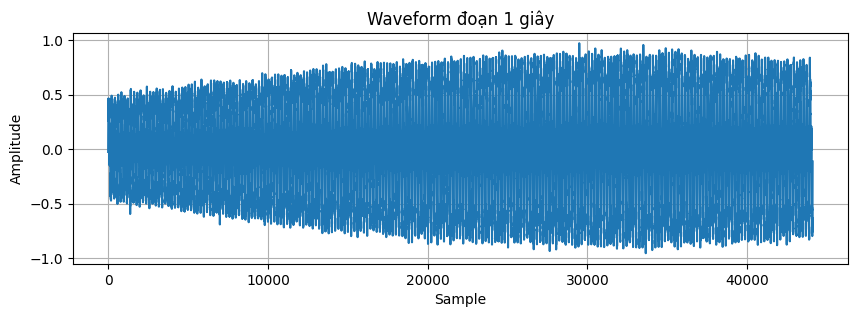

In [2]:
# B. Phân tích miền thời gian

peak = np.max(np.abs(x))
rms = np.sqrt(np.mean(x**2))
energy = np.sum(x**2)

print("Peak =", peak)
print("RMS =", rms)
print("Energy =", energy)

plt.figure(figsize=(12,4))
plt.plot(np.arange(len(x))/Fs,x)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Waveform toàn bộ tín hiệu")
plt.grid()
plt.savefig("figures/waveform.png",dpi=300)
plt.show()

# đoạn 1 giây
segment = x[:int(Fs)]

plt.figure(figsize=(10,3))
plt.plot(segment)
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.title("Waveform đoạn 1 giây")
plt.grid()
plt.show()


NFFT = 2048
Delta f = 21.533203125 Hz


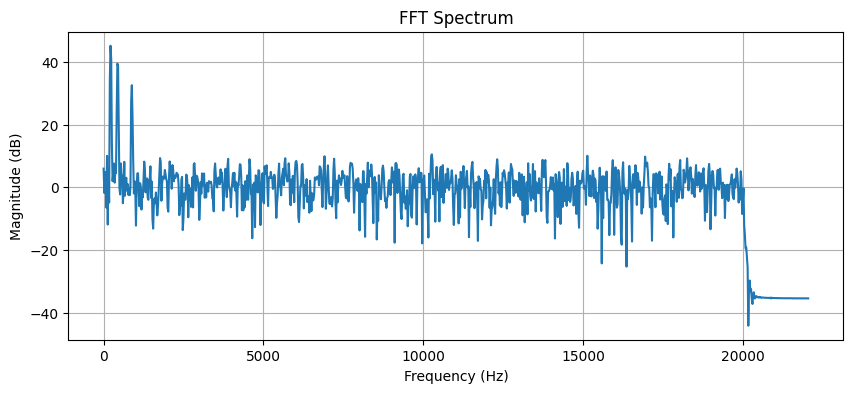

NFFT = 8192
Delta f = 5.38330078125 Hz


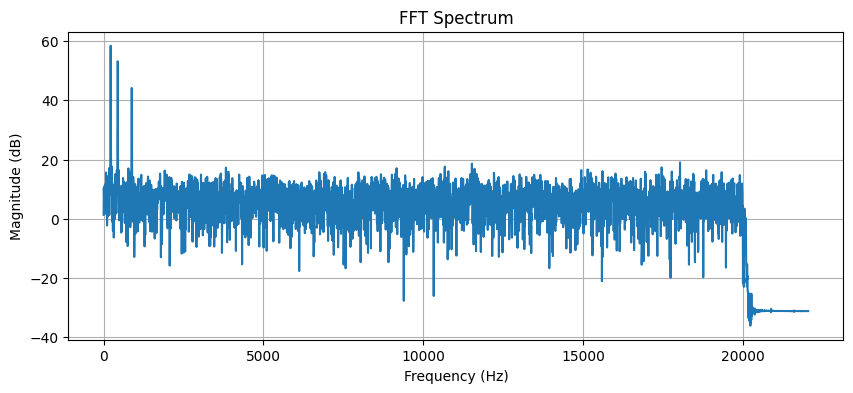

3 peak frequency:
215.33 Hz
441.43 Hz
220.72 Hz


In [3]:
# C. FFT bằng NumPy

segment = x[:int(Fs)]

for NFFT in [2048,8192]:

    frame = segment[:NFFT]
    frame = frame*np.hamming(len(frame))

    X = np.fft.rfft(frame,n=NFFT)
    freq = np.fft.rfftfreq(NFFT,1/Fs)

    mag_db = 20*np.log10(np.abs(X)+1e-12)

    print("NFFT =",NFFT)
    print("Delta f =",Fs/NFFT,"Hz")

    plt.figure(figsize=(10,4))
    plt.plot(freq,mag_db)
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Magnitude (dB)")
    plt.title("FFT Spectrum")
    plt.grid()

    if NFFT==8192:
        plt.savefig("figures/fft.png",dpi=300)

    plt.show()


# tìm 3 đỉnh phổ lớn
indices = np.argsort(mag_db)[-3:]

print("3 peak frequency:")
for i in indices:
    print(round(freq[i],2),"Hz")


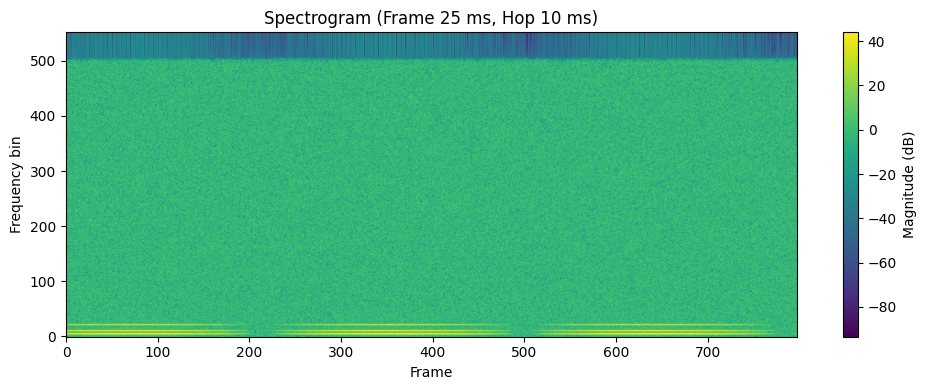

In [4]:
# D. STFT / Spectrogram bằng NumPy

def create_spectrogram(signal, fs, frame_ms, hop_ms):

    frame_length = int(frame_ms * fs / 1000)
    hop = int(hop_ms * fs / 1000)

    frames = []

    for i in range(0, len(signal)-frame_length, hop):
        frame = signal[i:i+frame_length]
        frame = frame * np.hamming(frame_length)
        frames.append(frame)

    frames = np.array(frames)

    spectrum = np.abs(
        np.fft.rfft(frames, axis=1)
    )

    return spectrum


# Lưu spectrogram chuẩn 25 ms / hop 10 ms
S = create_spectrogram(
    x,
    Fs,
    25,
    10
)

S_db = 20*np.log10(S.T + 1e-12)


plt.figure(figsize=(10,4))

plt.imshow(
    S_db,
    aspect="auto",
    origin="lower",
    cmap="viridis"
)

plt.title(
    "Spectrogram (Frame 25 ms, Hop 10 ms)"
)

plt.xlabel("Frame")
plt.ylabel("Frequency bin")

plt.colorbar(
    label="Magnitude (dB)"
)

plt.tight_layout()

plt.savefig(
    "figures/spectrogram.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

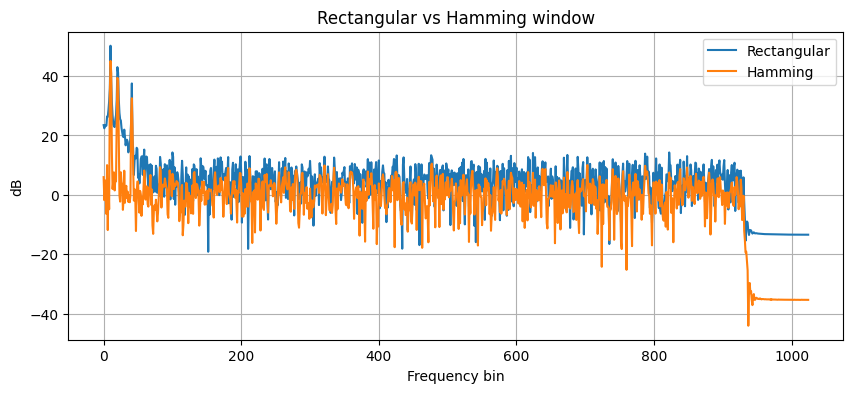

In [5]:
# E. Window experiment

N=2048
frame=x[:N]

plt.figure(figsize=(10,4))

for name,w in [
    ("Rectangular",np.ones(N)),
    ("Hamming",np.hamming(N))
]:

    X=np.fft.rfft(frame*w)

    mag=20*np.log10(
        np.abs(X)+1e-12
    )

    plt.plot(mag,label=name)


plt.xlabel("Frequency bin")
plt.ylabel("dB")
plt.title("Rectangular vs Hamming window")
plt.legend()
plt.grid()

plt.savefig(
    "figures/window_compare.png",
    dpi=300
)

plt.show()


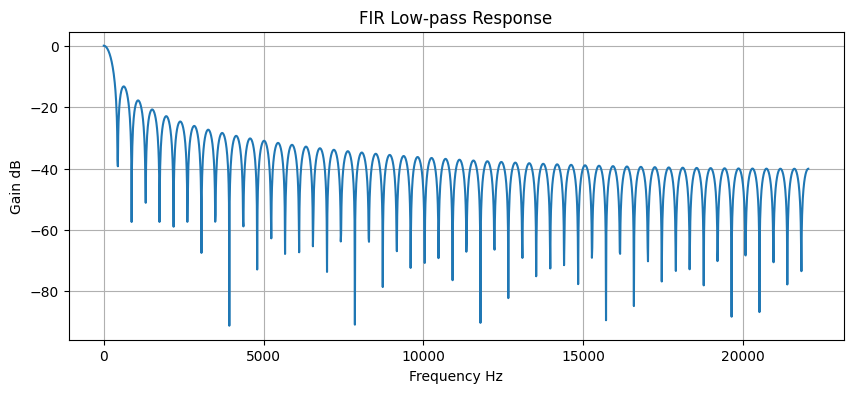

In [6]:
# F. FIR filter bằng NumPy convolution

# Low-pass moving average FIR
def fir_lowpass(signal, taps=101):

    h=np.ones(taps)/taps

    return np.convolve(
        signal,
        h,
        mode="same"
    )


filtered = fir_lowpass(x)

sf.write(
    "audio/filtered_lowpass.wav",
    filtered,
    Fs
)


# Đáp ứng tần số FIR
h=np.ones(101)/101

H=np.fft.rfft(h,4096)

freq=np.fft.rfftfreq(
    4096,
    1/Fs
)

plt.figure(figsize=(10,4))
plt.plot(
    freq,
    20*np.log10(abs(H)+1e-12)
)

plt.xlabel("Frequency Hz")
plt.ylabel("Gain dB")
plt.title("FIR Low-pass Response")
plt.grid()

plt.savefig(
    "figures/filter_response.png",
    dpi=300
)

plt.show()


In [7]:
# G. Quantization, SNR, Resampling, Coding

def quantize(x,B):

    levels=2**B

    return np.round(
        x*(levels/2-1)
    )/(levels/2-1)


def calculate_snr(x,xq):

    noise=x-xq

    return 10*np.log10(
        np.sum(x*x)/
        np.sum(noise*noise)
    )


for B in [4,8,16]:

    xq=quantize(x,B)

    print(
        B,
        "bit SNR =",
        calculate_snr(x,xq),
        "dB"
    )

    sf.write(
        f"audio/quantized_{B}bit.wav",
        xq,
        Fs
    )


# Resampling có anti-aliasing bằng NumPy
def fir_lowpass_resample(signal, fs_in, fs_out, numtaps=101):
    """Low-pass anti-alias FIR rồi nội suy tuyến tính về sampling rate mới."""
    if fs_out >= fs_in:
        # Trường hợp upsampling: nội suy trực tiếp
        t_old = np.arange(len(signal)) / fs_in
        n_new = int(round(len(signal) * fs_out / fs_in))
        t_new = np.arange(n_new) / fs_out
        return np.interp(t_new, t_old, signal)

    # Anti-aliasing: cutoff nhỏ hơn Nyquist của cả hai hệ
    cutoff = 0.45 * fs_out
    n = np.arange(numtaps) - (numtaps - 1) / 2
    h = 2 * cutoff / fs_in * np.sinc(2 * cutoff * n / fs_in)
    h *= np.hamming(numtaps)
    h /= np.sum(h)

    filtered_signal = np.convolve(signal, h, mode="same")

    # Nội suy sang sampling rate đích
    t_old = np.arange(len(filtered_signal)) / fs_in
    n_new = int(round(len(filtered_signal) * fs_out / fs_in))
    t_new = np.arange(n_new) / fs_out
    return np.interp(t_new, t_old, filtered_signal)


for new_fs in [16000, 8000]:
    y = fir_lowpass_resample(x, Fs, new_fs)

    sf.write(
        f"audio/resampled_{new_fs}Hz.wav",
        y.astype(np.float32),
        new_fs
    )

    print(
        f"Resampled: {Fs} Hz -> {new_fs} Hz | "
        f"Samples: {len(x)} -> {len(y)}"
    )


# PCM bitrate và compression ratio

bits=16
channels=1

pcm_rate=Fs*bits*channels

mp3_rate=128000

print("PCM bitrate =",pcm_rate,"bit/s")
print(
    "Compression ratio =",
    pcm_rate/mp3_rate
)


4 bit SNR = 18.369345662119546 dB
8 bit SNR = 43.43438059579921 dB
16 bit SNR = 91.66159133629503 dB
Resampled: 44100 Hz -> 16000 Hz | Samples: 352800 -> 128000
Resampled: 44100 Hz -> 8000 Hz | Samples: 352800 -> 64000
PCM bitrate = 705600 bit/s
Compression ratio = 5.5125


# Nhận xét kỹ thuật cần đưa vào báo cáo

- FFT với NFFT lớn làm giảm khoảng cách bin tần số Δf nhưng không tự tạo thêm thông tin.
- Cửa sổ Hamming giảm spectral leakage so với Rectangular.
- Spectrogram cho thấy sự thay đổi năng lượng theo thời gian.
- FIR filter làm thay đổi phổ theo đáp ứng tần số của bộ lọc.
- Tăng số bit lượng tử hóa làm SNR tăng.
- SNR cao không phải lúc nào cũng đồng nghĩa âm thanh nghe tốt hơn.


In [8]:
from pathlib import Path
# Kiểm tra các file đầu ra
print("\nCác file đầu ra đã tạo:")
for folder in ["figures", "audio"]:
    print(f"\n[{folder}/]")
    for f in sorted(Path(folder).glob("*")):
        print(" -", f.name)



Các file đầu ra đã tạo:

[figures/]
 - fft.png
 - filter_response.png
 - spectrogram.png
 - waveform.png
 - window_compare.png

[audio/]
 - filtered_lowpass.wav
 - quantized_16bit.wav
 - quantized_4bit.wav
 - quantized_8bit.wav
 - resampled_16000Hz.wav
 - resampled_8000Hz.wav
